## Nairobi Climate Time-Series Forecasting

In this notebook we will be building a time series forecasting and exploring Nairobi climate data.

## Import Libraries

In [1]:
# Import libraries for analysis

import pandas as pd                # For data analysis and manipulation
import numpy as np                 # For array handling and numerical operations
import matplotlib.pyplot as plt    # For static  plotting and visualizations
import seaborn as sns              # For beautiful statistical plotting & themes
from scipy.stats import pearsonr   # To calculate pearsons correlation
import warnings                    # To hide non critical warnings for a tidy notebook 
warnings.filterwarnings('ignore')

In [2]:
# Load data set, 
df = pd.read_csv("weather_data.csv", 
                 index_col = "year", parse_dates=True) # Set date column as index for timebase, convert date strings to date time objects
df.head()

,Nairobi_temp,Global_temp,Nairobi_avg,Global_avg
year,,,,
1850-01-01,15.33,7.90,15.53,8.065
1851-01-01,NaN,8.18,15.73,8.071
1852-01-01,NaN,8.10,15.73,8.038
1853-01-01,NaN,8.04,15.73,7.984
1854-01-01,NaN,8.21,15.73,7.991


In [3]:
# Check dataset information
df.info

<bound method DataFrame.info of             Nairobi_temp  Global_temp  Nairobi_avg  Global_avg
year                                                          
1850-01-01         15.33         7.90    15.530000    8.065000
1851-01-01           NaN         8.18    15.730000    8.071000
1852-01-01           NaN         8.10    15.730000    8.038000
1853-01-01           NaN         8.04    15.730000    7.984000
1854-01-01           NaN         8.21    15.730000    7.991000
...                  ...          ...          ...         ...
2009-01-01         17.30         9.51    16.954000    9.570000
2010-01-01         16.82         9.70    16.867500    9.585000
2011-01-01         16.90         9.52    16.883333    9.546667
2012-01-01         16.84         9.51    16.875000    9.560000
2013-01-01         16.91         9.61    16.910000    9.610000

[154 rows x 4 columns]>

In [4]:
# Check for null values
df.isnull().sum()

Nairobi_temp    13
Global_temp      0
Nairobi_avg      0
Global_avg       0
dtype: int64

In [5]:
# check data types
df.dtypes

Nairobi_temp    float64
Global_temp     float64
Nairobi_avg     float64
Global_avg      float64
dtype: object

### Observation
From the above analysis we observe that:
* Our data has 154 rows and 4 columns
* We have temprate and average for Nairobi and global
* All data types are of float
* The data frame has entries from 01-01-1850 to 01-01-2023
* We have 13 missing values under Nairobi_temp column (8%)

In [6]:
# Interpolate missing values since weather trends tend to change gradually
df['Nairobi_temp'] = df['Nairobi_temp'].interpolate(method='time')

# Counter check if any nulls remain
df.isnull().sum()

Nairobi_temp    0
Global_temp     0
Nairobi_avg     0
Global_avg      0
dtype: int64

In [7]:
# Countercheck data set for NaN values
df.head()

,Nairobi_temp,Global_temp,Nairobi_avg,Global_avg
year,,,,
1850-01-01,15.330000,7.90,15.53,8.065
1851-01-01,15.374417,8.18,15.73,8.071
1852-01-01,15.418835,8.10,15.73,8.038
1853-01-01,15.463374,8.04,15.73,7.984
1854-01-01,15.507791,8.21,15.73,7.991


In [8]:
# Check data set statistics

df.describe()

,Nairobi_temp,Global_temp,Nairobi_avg,Global_avg
count,154.000000,154.000000,154.000000,154.000000
mean,16.036752,8.575584,16.079575,8.619863
std,0.445737,0.467874,0.389336,0.456655
min,15.110000,7.560000,15.415000,7.943000
25%,15.686687,8.195000,15.775500,8.258500
50%,15.990000,8.575000,16.082500,8.619000
75%,16.325000,8.800000,16.306250,8.775500
max,17.300000,9.730000,16.954000,9.610000


### Observation
After cleaning the dataset of all  missing values the statistics are as:
* Minimum Temprature in Nairobi is 15° and 7° globally
* Maximum Temprature in Nairobi is 17° and 9° globally

## Data Exploration and Visualization


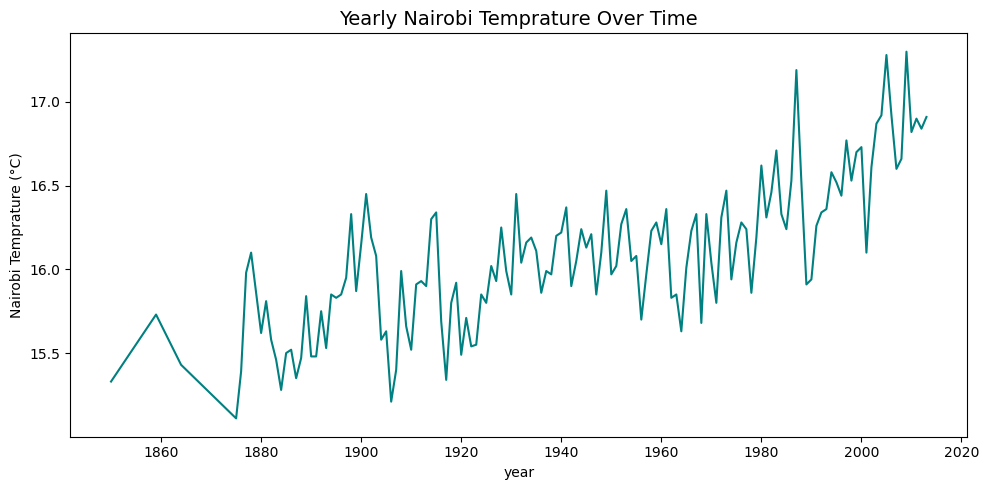

In [9]:
# Plot Line Plot Nairobi temprature over time using seaborn
plt.figure(figsize=(10,5)) # Set figure size

# line plot for nairobi temprature over time
sns.lineplot(data = df, x=df.index, y="Nairobi_temp", color='teal')

# Add title and axis labels
plt.title("Yearly Nairobi Temprature Over Time", fontsize=14)
plt.xlabel("year", fontsize=10)
plt.ylabel("Nairobi Temprature (°C)", fontsize=10)
plt.tight_layout()
plt.grid=True

# Show Plot
plt.show()

### Observation
From the above graph we observe that:
* The lowest tempratures were around 1870s
* The highest tempratures were around 2010
* Over the years the temprature has been varying with highs and lows but over the years there is a gradual increase

<function matplotlib.pyplot.show(close=None, block=None)>

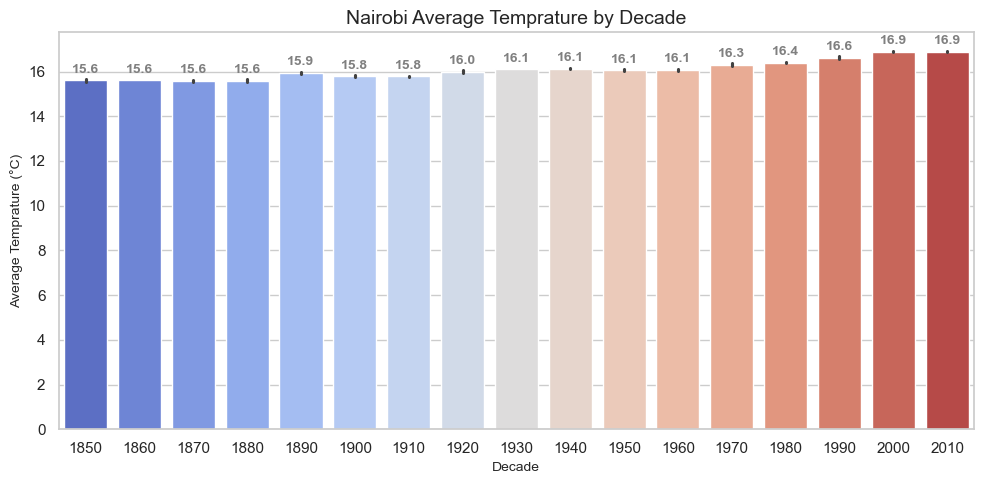

In [10]:
# Bar plot for Nairobi average temprature over the decades

# Set plot style
sns.set(style="whitegrid")

# create a year column
yearly_avg = df[['Nairobi_avg']].reset_index() 

# Group years by decade
yearly_avg['decade'] = (pd.to_datetime(yearly_avg['year']).dt.year // 10) * 10
decade_avg = yearly_avg.groupby('decade', as_index=False)['Nairobi_avg'].mean()

# Plot Nairobi average temprature by year using seaborn
plt.figure(figsize=(10,5))
sns.barplot(data=yearly_avg, x='decade', y='Nairobi_avg', palette='coolwarm')

# Add title and axis labels
plt.title('Nairobi Average Temprature by Decade', fontsize=14)
plt.xlabel('Decade', fontsize=10)
plt.ylabel('Average Temprature (°C)', fontsize=10)

# Add numeric values on bars
for index, row in decade_avg.iterrows():
    plt.text(row.name, row.Nairobi_avg + 0.2, f"{row.Nairobi_avg:.1f}",
             ha='center', va='bottom', fontsize=10, color='grey', fontweight='bold')

# Plot graph
plt.tight_layout()
plt.show

### Observation
From the above bar plot we observe that:
* In the early 1980s the average temprature in Nairobi was 15.6°C and by 2010 had raised to 16.9°C showing a gradual increase

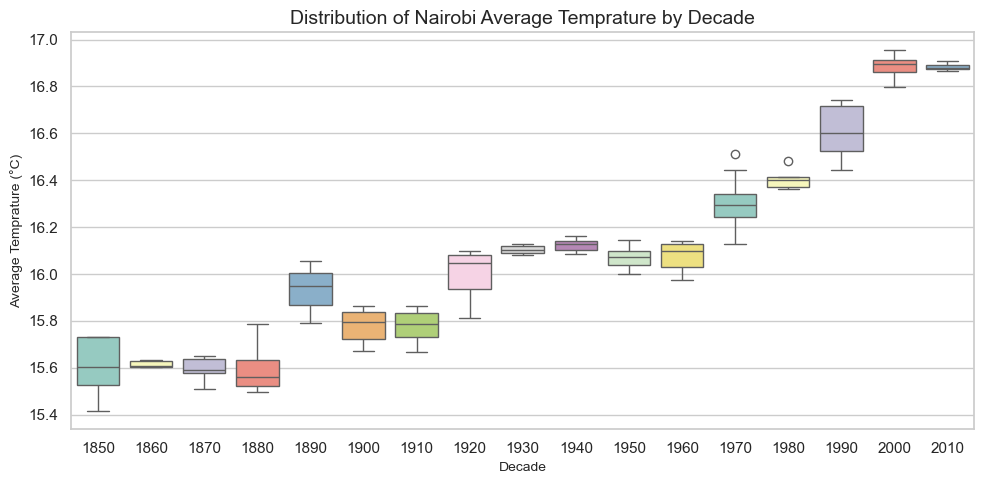

In [11]:
# Explore how temprature variates over each decade using seaborn box plot

# Plot Nairobi average temprature by year using seaborn
plt.figure(figsize=(10,5))

# Draw box plot to show distribution
sns.boxplot(data=yearly_avg, x='decade', y='Nairobi_avg', palette='Set3')

# Add title and axis labels
plt.title('Distribution of Nairobi Average Temprature by Decade', fontsize=14)
plt.xlabel('Decade', fontsize=10)
plt.ylabel('Average Temprature (°C)', fontsize=10)

# Plot box plot
plt.tight_layout()
plt.show()

### Observation
From the above box plot we observe that:
* Peak Temprature are highest inbetween 2000 and 2009
* Lowest Temprature were inbetween 1880 and 1889
* There are notable outliers inbetween 1979 and 1980 likely due to abnormal climate events such as droughts or heat waves

In [12]:
# Explore dataset with a function to find outliers over the years

def find_outliers(group):
    D1 = group['Nairobi_avg'].quantile(0.25)
    D3 = group['Nairobi_avg'].quantile(0.75)
    IQR = D3 - D1
    lower = D1 - 1.5 * IQR
    upper = D3 + 1.5 * IQR
    return group[(group['Nairobi_avg'] < lower) | (group['Nairobi_avg'] > upper)]

df['decade'] = (df.index.year // 10) * 10
outlier_years = df.groupby('decade').apply(find_outliers)

print(outlier_years)

                   Nairobi_temp  Global_temp  Nairobi_avg  Global_avg  decade
decade year                                                                  
1970   1979-01-01         16.19         8.73       16.510       8.892    1970
1980   1980-01-01         16.62         8.98       16.482       8.911    1980


### Observation
The above analysis confirms there are outliers in 1979 and 1980 with higher than usual tempratures however
since climate temprature can variate due to climatic irregularities, such as droughts, El Niño events, or data recording inconsistencies
we will keep the outliers in this analysis otherwise normally we would interpolate.

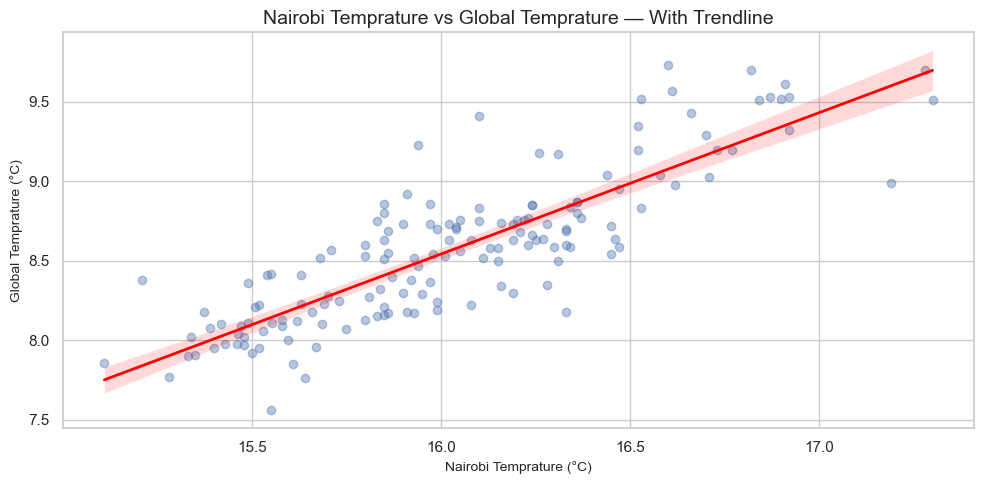

In [13]:
# Plot scatterplot for Nairobi Temprature vs global temprature 

# Plot scatter plot by using seaborn
plt.figure(figsize=(10,5))

# Draw box plot to show distribution
sns.regplot(data=df, x='Nairobi_temp', y='Global_temp', scatter_kws={'alpha':0.4},
           line_kws={'color':'red','lw': 2},)

# Add title and axis labels
plt.title('Nairobi Temprature vs Global Temprature — With Trendline', fontsize=14)
plt.xlabel('Nairobi Temprature (°C)', fontsize=10)
plt.ylabel('Global Temprature (°C)', fontsize=10)

# Plot scatter plot
plt.tight_layout()
plt.grid=True
plt.show()

In [14]:
# Calculate pearsons correlation
corr, _ = pearsonr(df['Nairobi_temp'], df['Global_temp'])

print('Pearson’s Correlation: %.3f' % corr)

Pearson’s Correlation: 0.847


### Observation
From the scatter plot we observe:
* A positive correlation as Nairobi temprature increases global tempratures increase as well
* The pearson correlation between Nairobi and global tempratures is 0.847 indicating a positive linear relationship

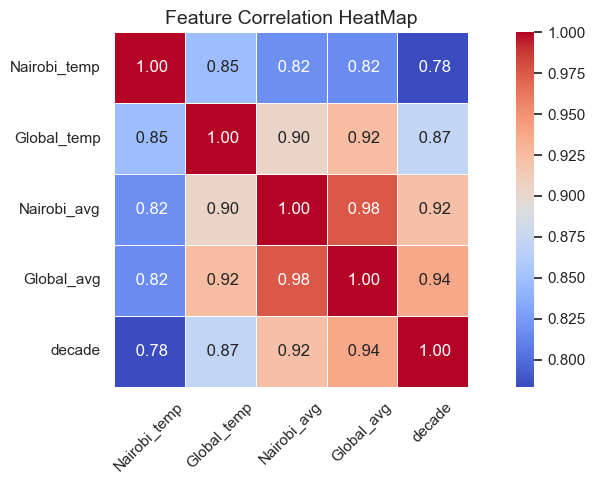

In [15]:
# Plot Correlation matrix using heat map for Nairobi Temprature

# Plot heatmap plot by using seaborn
plt.figure(figsize=(10,5))

# Draw heatmap plot to show distribution
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=" .2f", linewidths=0.5, square=True)

# Add title and axis labels
plt.title('Feature Correlation HeatMap', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Plot box plot
plt.tight_layout()
plt.show()

### Observation
* The heatmap shows Nairobi and global temprature have a positive correlation of 0.85, meaning both tempratures rise gradually.
* Additionally the Nairobi and global average tempratures also have a positive correlation of 0.82

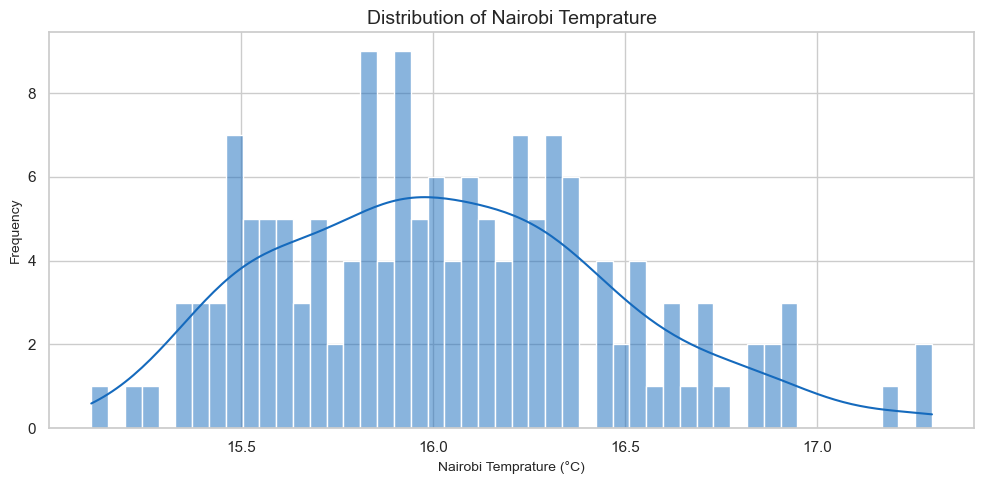

In [17]:
# Plot distribution for Nairobi Temprature

# Plot scatter plot by using seaborn
plt.figure(figsize=(10,5))

# Draw histogram plot to show distribution
sns.histplot(data=df, x='Nairobi_temp', bins=50, color='#156abd', kde=True)

# Add title and axis labels
plt.title('Distribution of Nairobi Temprature', fontsize=14)
plt.xlabel('Nairobi Temprature (°C)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

# Plot box plot
plt.tight_layout()
plt.grid=True
plt.show()

### Observation
From the histogram we observe:
* The highest frequency is between 15.5° and 16.0°
* Left skewed distribution indicating more frequent low tempratures
* Outliers few tempratures after 17°

## Conclusion
This analysis demonstrates a clear warming trend in Nairobi, with a strong positive correlation to global temperatures. Recognizing these shifts is critical for UNEP’s climate adaptation and resilience planning in East Africa.